# How to think in Jax

Jax is a library for array-oriented numerical computation with automatic differentiation and JIT compilation to enable high-performance machine learning research.

This notebook provides a quick overview of essential JAX features so you can get started:

1. Jax Provides a unified Numpy-like interface to computation that run on  CPU , GPU or TPU ,in local or distributed settings.
2.  Jax features built-in Just-In-Time(JIT) compilation via OpenXLA and open source machine learning compiler ecosystem.
3. Jax functions supports efficient evaluation of gradients via its automatic differentiation transformations.
4. Jax functions can be automatically vectorized to efficiently map them over arrays representing batches of inputs.

## 1. Installation

Jax can be installed for CPU on linux , Windows and macOS directly from the [Python Package Index](https://pypi.org/project/jax/)

```
pip install jax
```
or for Nvidia GPU:

```
pip install -U "jax[cuda13]"

```

For more detailed platform-specific installation information, check out [installation](https://docs.jax.dev/en/latest/installation.html)


## 2. Jax vs Numpy

Key Concepts:

1. Jax Provides a Numpy-inspired interface for convenience.
2. Through [duck-typing](https://en.wikipedia.org/wiki/Duck_typing) , JAX arrays can often be used as a drop-in replacements  of Numpy arrays.
3. Unlike Numpy arrays, JAX arrays are always immutable.

Numpy provides a well-known , powerfulAPI for working with Numerical data. For convenience Jax provides `jax.numpy` which closely mirrors the nunpy API and provides easy entry into JAX. Almost anything that can be done with `numpy` can be done with `jax.numpy` which is typically imported under `jnp` alias

In [1]:
import jax.numpy as jnp

With this import, you can immediately use JAX in a similar manner to typical NumPy programs, including using NumPy-style array creation functions, Python functions and operators, and array attributes and methods:

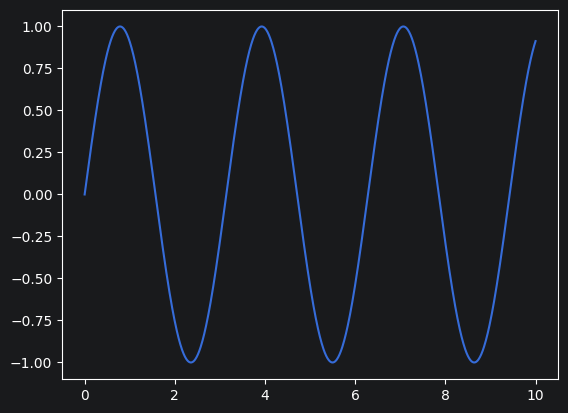

In [2]:
import matplotlib.pyplot as plt

x_jnp = jnp.linspace(0,10,1000)
y_jnp = 2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)
plt.plot(x_jnp,y_jnp)

The code blocks are identical to what you would expect with NumPy, aside from replacing `np` with `jnp`, and the results are the same. As we can see, JAX arrays can often be used directly in place of NumPy arrays for things like plotting.

The arrays themselves are implemented as different Python types:

In [3]:
import numpy as np
import jax.numpy as jnp

x_np = jnp.linspace(0,10,1000)
y_jnp = np.linspace(0,10,1000)

In [4]:
type(x_np)

jaxlib._jax.ArrayImpl

Python’s duck-typing allows JAX arrays and NumPy arrays to be used interchangeably in many places. However, there is one important difference between JAX and NumPy arrays: JAX arrays are immutable, meaning that once created their contents cannot be changed.

Here is an example of mutating an array in NumPy:



In [6]:
x = np.arange(10)
x[0] =  10
print(x)

[10  1  2  3  4  5  6  7  8  9]


The equivalent in JAX results in an error, as JAX arrays are immutable:



In [7]:
%xmode minimal

Exception reporting mode: Minimal


In [8]:
x = jnp.arange(10)
x[0] =  10

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

For updating individual elements, JAX provides an [indexed update syntax](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html#jax-numpy-ndarray-at) that returns an updated copy:

In [10]:
y = x.at[0].set(10)
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[10  1  2  3  4  5  6  7  8  9]


You’ll find a few differences between JAX arrays and NumPy arrays once you begin digging in.

## 3. JAX arrays(`jax.Array`)